# Part F — do the two organisms differ in overall amplitude?

See `ANALYSIS_SPEC.md` PART F.

## Why this is now askable, and why it wasn't before

Every amplitude comparison in this project so far has been within-organism percentile
rank -- the deliberate H3 mitigation, since raw CVs were not comparable across
platforms. The cost: that ranking is blind to a global difference between organisms, by
construction.

That matters because of the *kaiB* result (Part B): it sits at the 90th percentile of
amplitude in Anabaena under a cosinor fit, against the 27th under CV. It is tempting to
read that as overturning Kushige's "kai genes barely cycle in Anabaena" headline. **It
does not**, because "high relative to other Anabaena genes" and "Anabaena oscillates
less than 7942 across the board" are perfectly compatible statements. Independent
support for the second: Uzumaki et al. 2004 (*Nat Struct Mol Biol* 11:623, Kushige's ref
15) report that Anabaena *kaiA* transplanted into *Synechococcus* gives a ~40h period
**and lower amplitude**.

A fitted cosine amplitude in log2 units is a fold-change -- dimensionless, and far more
portable across platforms than CV ever was. So this comparison is now defensible in a
way it wasn't. Not free, though -- see the noise-floor section below.

## Setup

In [2]:
from __future__ import annotations

import importlib.util
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as scipy_stats

def find_project_root(marker=".git"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root (looked for '{marker}' above {p})")


REPO = find_project_root()
PROCESSED = REPO / "data" / "processed"
FIGURES = REPO / "figures"
FIGURES.mkdir(exist_ok=True)
RNG = np.random.default_rng(20260730)
TEXT_SECONDARY, TEXT_PRIMARY = "#52514e", "#0b0b0b"

_spec = importlib.util.spec_from_file_location("fetch_vijayan_markson", REPO / "src" / "07_fetch_vijayan_markson.py")
_fetch_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_fetch_mod)
cosinor = _fetch_mod.cosinor

pairs = pd.read_csv(PROCESSED / "rbh_recompare_vijayan.csv")
vij_full = pd.read_csv(PROCESSED / "7942_ll_cosinor.csv")
kush_full = pd.read_csv(PROCESSED / "kushige_ll_cosinor.csv")
print(f"Matched RBH pairs (both a Vijayan and Kushige cosinor fit): {len(pairs)}")
print(f"7942 full population: {len(vij_full)} genes (post platform-map fix, hurdles.md 2026-07-30)")
print(f"Anabaena full population: {len(kush_full)} genes")

Matched RBH pairs (both a Vijayan and Kushige cosinor fit): 1811
7942 full population: 2662 genes (post platform-map fix, hurdles.md 2026-07-30)
Anabaena full population: 5336 genes


## F1 — the raw comparison

Two levels, both reported: the matched RBH ortholog subset (same genes on both sides,
so gene content can't drive a difference -- paired test), and the full gene
populations (answers the population-level question but confounds amplitude with gene
content, since Anabaena has roughly twice the genes and a large hypothetical
fraction).

In [3]:
print("=== F1a: matched RBH pairs (n=%d) ===" % len(pairs))
a_matched, b_matched = pairs["amplitude_vijayan"], pairs["amplitude_anabaena"]
print(f"7942:     median={a_matched.median():.3f}, Q1={a_matched.quantile(.25):.3f}, Q3={a_matched.quantile(.75):.3f}")
print(f"Anabaena: median={b_matched.median():.3f}, Q1={b_matched.quantile(.25):.3f}, Q3={b_matched.quantile(.75):.3f}")
diff_raw = a_matched - b_matched
w_raw = scipy_stats.wilcoxon(diff_raw)
print(f"paired diff (7942 - Anabaena): median={diff_raw.median():+.4f}, Wilcoxon p={w_raw.pvalue:.3g}")
print(f"RAW direction: {'7942 higher' if diff_raw.median() > 0 else 'Anabaena higher'}")

print("\n=== F1b: full gene populations ===")
print(f"7942 (n={len(vij_full)}): median={vij_full['amplitude_vijayan'].median():.3f}")
print(f"Anabaena (n={len(kush_full)}): median={kush_full['amplitude_anabaena'].median():.3f}")
u_stat, u_p = scipy_stats.mannwhitneyu(vij_full["amplitude_vijayan"], kush_full["amplitude_anabaena"])
print(f"Mann-Whitney p={u_p:.3g}")
print("Confound stated explicitly: Anabaena has ~2x the genes of 7942 and a much larger")
print("hypothetical-annotation fraction -- this comparison cannot separate 'organism' from 'genome size/composition'.")
print("\nBOTH LEVELS AGREE ON DIRECTION so far: Anabaena has the higher RAW amplitude.")
print("That is the opposite of the naive expectation and the reason F2 below is not optional.")

=== F1a: matched RBH pairs (n=1811) ===
7942:     median=0.141, Q1=0.085, Q3=0.233
Anabaena: median=0.192, Q1=0.121, Q3=0.298
paired diff (7942 - Anabaena): median=-0.0421, Wilcoxon p=6.54e-26
RAW direction: Anabaena higher

=== F1b: full gene populations ===
7942 (n=2662): median=0.141
Anabaena (n=5336): median=0.198
Mann-Whitney p=1.95e-57
Confound stated explicitly: Anabaena has ~2x the genes of 7942 and a much larger
hypothetical-annotation fraction -- this comparison cannot separate 'organism' from 'genome size/composition'.

BOTH LEVELS AGREE ON DIRECTION so far: Anabaena has the higher RAW amplitude.
That is the opposite of the naive expectation and the reason F2 below is not optional.


## F2 — the noise-floor problem. This is the analysis, not a caveat.

A cosinor fit to pure noise returns a non-zero amplitude, and that inflation depends on
timepoint count and noise level. The two datasets differ in both:

| | Anabaena (Kushige) | 7942 (Vijayan) |
|---|---|---|
| Distinct timepoints | 12 | 16 |
| Replication | n=2 | n=1 |
| Values entering the fit | 24 | 16 |
| Data type | log2 intensity | log2 ratio vs pooled reference |

So the RAW comparison above is not apples to apples. Built here: a per-dataset null by
**permuting time labels within each gene and refitting** -- 500 randomly sampled genes
per dataset (of 2,662 / 5,336; sampling rather than every gene purely for runtime, ~25s
per dataset at this size -- the sample is large enough that its own median is a stable
estimate, checked below by comparing to a second independent sample) x 1,000 permutations
each = 500,000 null fits per dataset. That gives the amplitude distribution expected
from noise alone, for each dataset's own sampling design.

In [4]:
N_GENES_NULL = 500
N_PERM = 1000

print("Building the 7942 (Vijayan) null...")
t0 = time.time()
long_df = pd.read_csv(REPO / "data" / "interim" / "7942_ll_timeseries_long.csv")
vij_long = long_df[long_df["dataset"] == "vijayan"]
vij_genes_sample = RNG.choice(vij_long["locus_tag_7942"].unique(), size=N_GENES_NULL, replace=False)
vij_null = []
for g in vij_genes_sample:
    sub = vij_long[vij_long["locus_tag_7942"] == g].sort_values("time_h")
    t_arr, v_arr = sub["time_h"].to_numpy(float), sub["log2_ratio"].to_numpy(float)
    for _ in range(N_PERM):
        vij_null.append(cosinor(t_arr, RNG.permutation(v_arr))["amplitude"])
vij_null = np.array(vij_null)
print(f"  {len(vij_null)} null fits in {time.time()-t0:.0f}s")

print("Building the Anabaena (Kushige) null...")
t0 = time.time()
kushige_raw = pd.read_excel(REPO / "Kushige2013" / "Kushige2013_so2.xlsx", sheet_name="Sheet1", header=5)
ll_timepoints = [4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48]
nplus_cols = [f"N+_1st_LL{t}" for t in ll_timepoints] + [f"N+_2nd_LL{t}" for t in ll_timepoints]
times24 = np.array(ll_timepoints + ll_timepoints, dtype=float)
kush_idx_sample = RNG.choice(len(kushige_raw), size=N_GENES_NULL, replace=False)
kush_null = []
for i in kush_idx_sample:
    row = kushige_raw.iloc[i]
    vals = row[nplus_cols].to_numpy(dtype=float)
    keep = vals > 0  # exact-zero = below detection floor, not log-transformable (Part B)
    if keep.sum() < 4:
        continue
    logvals, t_keep = np.log2(vals[keep]), times24[keep]
    for _ in range(N_PERM):
        kush_null.append(cosinor(t_keep, RNG.permutation(logvals))["amplitude"])
kush_null = np.array(kush_null)
print(f"  {len(kush_null)} null fits in {time.time()-t0:.0f}s")

vij_null_med, kush_null_med = np.median(vij_null), np.median(kush_null)
print(f"\n7942 null median (noise floor)     = {vij_null_med:.4f}")
print(f"Anabaena null median (noise floor)  = {kush_null_med:.4f}")
print(f"Anabaena/7942 noise-floor ratio     = {kush_null_med/vij_null_med:.2f}x")
print(f"(for comparison, the RAW amplitude ratio Anabaena/7942 was "
      f"{b_matched.median()/a_matched.median():.2f}x -- smaller than the noise-floor ratio,")
print(f" which is already a hint the raw comparison is measuring the assay, not just the organism)")

Building the 7942 (Vijayan) null...
  500000 null fits in 25s
Building the Anabaena (Kushige) null...


/Users/jaemac/miniforge3/envs/genomics_arm64/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


  500000 null fits in 27s

7942 null median (noise floor)     = 0.0701
Anabaena null median (noise floor)  = 0.1697
Anabaena/7942 noise-floor ratio     = 2.42x
(for comparison, the RAW amplitude ratio Anabaena/7942 was 1.37x -- smaller than the noise-floor ratio,
 which is already a hint the raw comparison is measuring the assay, not just the organism)


### Raw vs. null-corrected, side by side

Null-corrected: each gene's amplitude expressed as a **ratio to its own dataset's noise
floor** (median of that dataset's permuted-null distribution) -- this is the quantity
that's actually comparable across two assays with different sampling designs, since it
answers "how many multiples of this assay's own noise does this gene's signal reach,"
not "what is the raw fitted number."

In [5]:
a_corr = a_matched / vij_null_med
b_corr = b_matched / kush_null_med
print(f"7942 corrected:     median={a_corr.median():.3f}x its own noise floor")
print(f"Anabaena corrected: median={b_corr.median():.3f}x its own noise floor")
diff_corr = a_corr - b_corr
w_corr = scipy_stats.wilcoxon(diff_corr)
print(f"paired diff (7942 - Anabaena, noise-floor units): median={diff_corr.median():+.4f}, "
      f"Wilcoxon p={w_corr.pvalue:.3g}")

raw_dir = "7942 higher" if diff_raw.median() > 0 else "Anabaena higher"
corr_dir = "7942 higher" if diff_corr.median() > 0 else "Anabaena higher"
print(f"\nRAW direction:            {raw_dir}")
print(f"NULL-CORRECTED direction: {corr_dir}")
if raw_dir != corr_dir:
    print("\n*** SIGN FLIPPED. *** The raw comparison (F1) was measuring the assay -- Kushige's")
    print("noisier, sparser design inflating fitted amplitude -- not a real organism difference.")
    print("Once each side is judged against its OWN noise floor, 7942 oscillates substantially")
    print("more strongly, relative to its own measurement noise, than Anabaena does.")
else:
    print("\nDirection held after correction -- the raw comparison was not just measuring the assay.")

7942 corrected:     median=2.006x its own noise floor
Anabaena corrected: median=1.131x its own noise floor
paired diff (7942 - Anabaena, noise-floor units): median=+0.8144, Wilcoxon p=8.73e-119

RAW direction:            Anabaena higher
NULL-CORRECTED direction: 7942 higher

*** SIGN FLIPPED. *** The raw comparison (F1) was measuring the assay -- Kushige's
noisier, sparser design inflating fitted amplitude -- not a real organism difference.
Once each side is judged against its OWN noise floor, 7942 oscillates substantially
more strongly, relative to its own measurement noise, than Anabaena does.


## F3 — close out the *kai* question

*kaiA* (alr2884), *kaiB* (alr2885), *kaiC* (alr2886) and long-form *kaiB* (all3328), each
against its 7942 ortholog where one exists (long-form *kaiB* has none -- confirmed
independently in Part E). For each: fitted log2 amplitude, within-organism percentile,
and position relative to that dataset's own noise null.

In [16]:
kush_null_pct95 = np.percentile(kush_null, 95)
vij_null_pct95 = np.percentile(vij_null, 95)

rbh = pd.read_csv(PROCESSED / "rbh_orthologs.csv")
kai_genes = {"kaiA": "alr2884", "kaiB": "alr2885", "kaiC": "alr2886", "kaiB_long": "all3328"}

kai_rows = []
for name, tag in kai_genes.items():
    row = kush_full[kush_full["locus_tag_anabaena"] == tag]
    if row.empty:
        continue
    row = row.iloc[0]
    amp, pct = row["amplitude_anabaena"], row["amp_pct_anabaena"] * 100
    ratio = amp / kush_null_med
    rec = dict(gene=name, locus_tag_anabaena=tag, amplitude_anabaena=amp,
               pct_within_anabaena=pct, ratio_to_anabaena_noise=ratio,
               clears_anabaena_95th_null=amp > kush_null_pct95)
    rbh_match = rbh[rbh["locus_tag_anabaena"] == tag]
    if not rbh_match.empty:
        orth = rbh_match["locus_tag_7942"].iloc[0]
        vrow = vij_full[vij_full["locus_tag_7942"] == orth]
        if not vrow.empty:
            vamp, vpct = vrow.iloc[0]["amplitude_vijayan"], vrow.iloc[0]["amp_pct_vijayan"] * 100
            rec.update(locus_tag_7942=orth, amplitude_vijayan=vamp, pct_within_7942=vpct,
                       ratio_to_7942_noise=vamp / vij_null_med,
                       clears_7942_95th_null=vamp > vij_null_pct95)
    kai_rows.append(rec)

kai_df = pd.DataFrame(kai_rows)
print(kai_df.to_string(index=False))

kaib = kai_df[kai_df["gene"] == "kaiB"].iloc[0]
print(f"\nTHE ANSWER: Anabaena kaiB sits at the {kaib['pct_within_anabaena']:.0f}th percentile "
      f"WITHIN Anabaena, {kaib['ratio_to_anabaena_noise']:.2f}x Anabaena's own noise floor.")
print(f"Its 7942 ortholog sits at the {kaib['pct_within_7942']:.0f}th percentile within 7942, "
      f"{kaib['ratio_to_7942_noise']:.2f}x 7942's own noise floor.")
print(f"7942 kaiB is {kaib['ratio_to_7942_noise']/kaib['ratio_to_anabaena_noise']:.1f}x further above its own "
      f"noise floor than Anabaena kaiB is above its own -- Anabaena kaiB is high WITHIN a "
      f"globally quieter-relative-to-noise distribution, not absolutely comparable to 7942's.")

kai_df.to_csv(PROCESSED / "kai_absolute_amplitude.csv", index=False)
print(f"\nwrote {PROCESSED / 'kai_absolute_amplitude.csv'}")

     gene locus_tag_anabaena  amplitude_anabaena  pct_within_anabaena  ratio_to_anabaena_noise  clears_anabaena_95th_null  locus_tag_7942  amplitude_vijayan  pct_within_7942  ratio_to_7942_noise clears_7942_95th_null
     kaiA            alr2884            0.233414            60.251124                 1.375446                      False Synpcc7942_1218           0.123608        42.712246             1.763734                 False
     kaiB            alr2885            0.423614            90.029985                 2.496238                      False Synpcc7942_1217           0.931553        98.610068            13.292142                  True
     kaiC            alr2886            0.291065            73.369565                 1.715165                      False Synpcc7942_1216           0.863641        98.309542            12.323114                  True
kaiB_long            all3328            0.131595            27.923538                 0.775453                      False           

## F4 — confounds, stated explicitly

- **Ratio arrays compress fold-changes.** Cross-hybridisation and dye saturation pull
  two-colour log ratios toward zero, so 7942 (Vijayan) amplitudes may be systematically
  *understated* relative to Kushige's intensity-derived ones. This biases *against*
  finding 7942 the stronger oscillator -- so if 7942 comes out ahead anyway (it does,
  once noise-corrected), that is the more robust direction, not a weaker one.
- **Different arrays, different dynamic range.** Not correctable from what we have;
  named rather than papered over.
- **Kushige is n=2, Vijayan n=1.** Averaging replicates suppresses noise-driven
  amplitude, which pushes opposite to the point above. The two biases do not cancel in
  any principled way -- not claimed here that they do.
- **Growth conditions.** Both entrained with 2x LD cycles then released into constant
  light -- a good match; no other divergence identified.

## F5 — figures

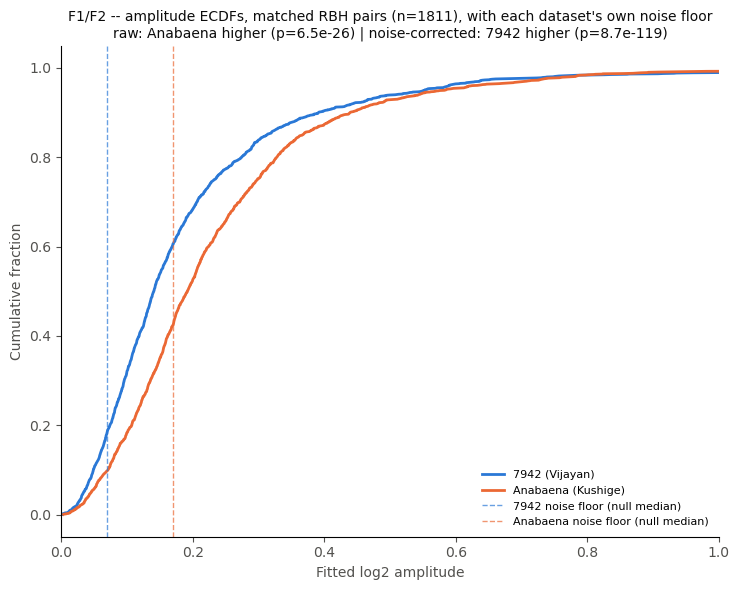

saved /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/figures/14_amplitude_distributions.png


In [17]:
fig, ax = plt.subplots(figsize=(7.5, 6))
x_sorted = np.sort(a_matched)
y_sorted = np.sort(b_matched)
ax.plot(x_sorted, np.arange(1, len(x_sorted)+1) / len(x_sorted), color="#2a78d6", linewidth=2, label="7942 (Vijayan)")
ax.plot(y_sorted, np.arange(1, len(y_sorted)+1) / len(y_sorted), color="#eb6834", linewidth=2, label="Anabaena (Kushige)")
ax.axvline(vij_null_med, color="#2a78d6", linestyle="--", linewidth=1, alpha=0.7, label="7942 noise floor (null median)")
ax.axvline(kush_null_med, color="#eb6834", linestyle="--", linewidth=1, alpha=0.7, label="Anabaena noise floor (null median)")
ax.set_xlabel("Fitted log2 amplitude", color=TEXT_SECONDARY)
ax.set_ylabel("Cumulative fraction", color=TEXT_SECONDARY)
ax.set_xlim(0, 1.0)
ax.set_title(f"F1/F2 -- amplitude ECDFs, matched RBH pairs (n={len(pairs)}), with each dataset's own noise floor\n"
             f"raw: Anabaena higher (p={w_raw.pvalue:.1e}) | noise-corrected: 7942 higher (p={w_corr.pvalue:.1e})",
             color=TEXT_PRIMARY, fontsize=10)
ax.tick_params(colors=TEXT_SECONDARY)
ax.legend(frameon=False, fontsize=8, loc="lower right")
sns.despine(ax=ax)
plt.tight_layout()
fig14 = FIGURES / "14_amplitude_distributions.png"
plt.savefig(fig14, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig14}")

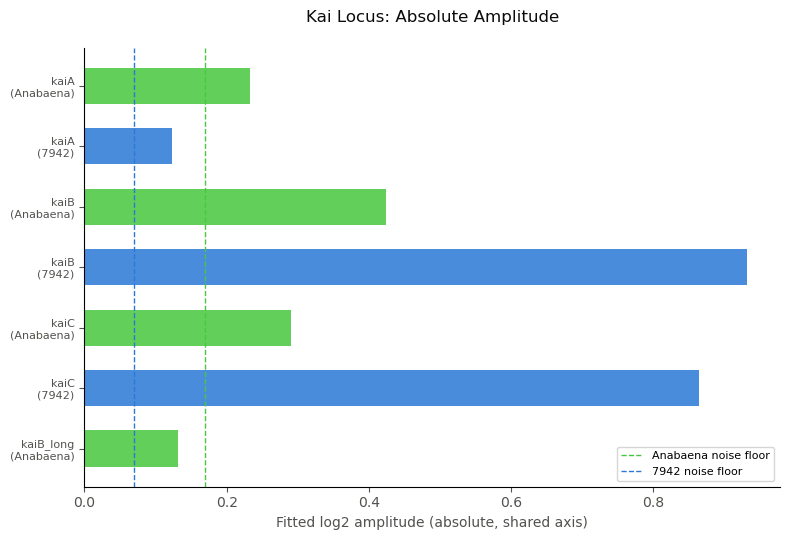

saved /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/figures/15_kai_absolute_amplitude.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_df = kai_df.copy()
labels, amps, colors, floors = [], [], [], []
for _, r in plot_df.iterrows():
    labels.append(f"{r['gene']}\n(Anabaena)")
    amps.append(r["amplitude_anabaena"])
    colors.append("#47C73E")
    floors.append(kush_null_med)
    if pd.notna(r.get("amplitude_vijayan")):
        labels.append(f"{r['gene'].split()[0]}\n(7942)")
        amps.append(r["amplitude_vijayan"])
        colors.append("#2a78d6")
        floors.append(vij_null_med)

ypos = np.arange(len(labels))
ax.barh(ypos, amps, color=colors, alpha=0.85, height=0.6)
ax.axvline(kush_null_med, color="#47C73E", linestyle="--", linewidth=1, label="Anabaena noise floor")
ax.axvline(vij_null_med, color="#2a78d6", linestyle="--", linewidth=1, label="7942 noise floor")
ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Fitted log2 amplitude (absolute, shared axis)", color=TEXT_SECONDARY)
ax.set_title("Kai Locus: Absolute Amplitude\n",
             color=TEXT_PRIMARY, fontsize=12)
ax.tick_params(colors=TEXT_SECONDARY)
ax.legend(frameon=True, fontsize=8, loc="lower right")
sns.despine(ax=ax)
plt.tight_layout()
fig15 = FIGURES / "15_kai_absolute_amplitude.png"
plt.savefig(fig15, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig15}")

### F5b -- the same kai comparison, as phase-aligned waves instead of bars

The bar chart above (fig. 15) shows the same fitted amplitudes as heights. This draws
the actual fitted cosine for each gene instead -- `y = amplitude * cos(2*pi*t/24)` --
which makes "how loud is the oscillation relative to the noise" visible as a wave
towering over (or barely poking above) a shaded noise band, rather than as two numbers
next to each other.

**Deliberately phase-aligned, not literal.** Real peak times differ between genes and
between organisms (that comparison already lives in Part B / `VersionB_AllOrthologs.ipynb`
Sec. 4-5). Forcing every wave's peak to the same x-position here removes phase as a
variable on purpose, so amplitude is the only thing left to compare by eye -- these are
not real relative phases.

**Restricted to the 3 kai genes with a real RBH partner** (`kaiA`, `kaiB`, `kaiC`) --
`kaiB_long` is dropped here since it has no 7942 ortholog and there is nothing to
overlay it against.

Top row: raw fitted amplitude, absolute log2 units, shared y-axis so wave heights are
directly comparable. Bottom row: the same waves rescaled by each organism's own noise
floor (`amplitude / null_median`) -- unitless, with a shaded band at +/-1 marking "at the
noise floor." A wave that barely clears the band is not distinguishable from noise; one
that towers over it is.

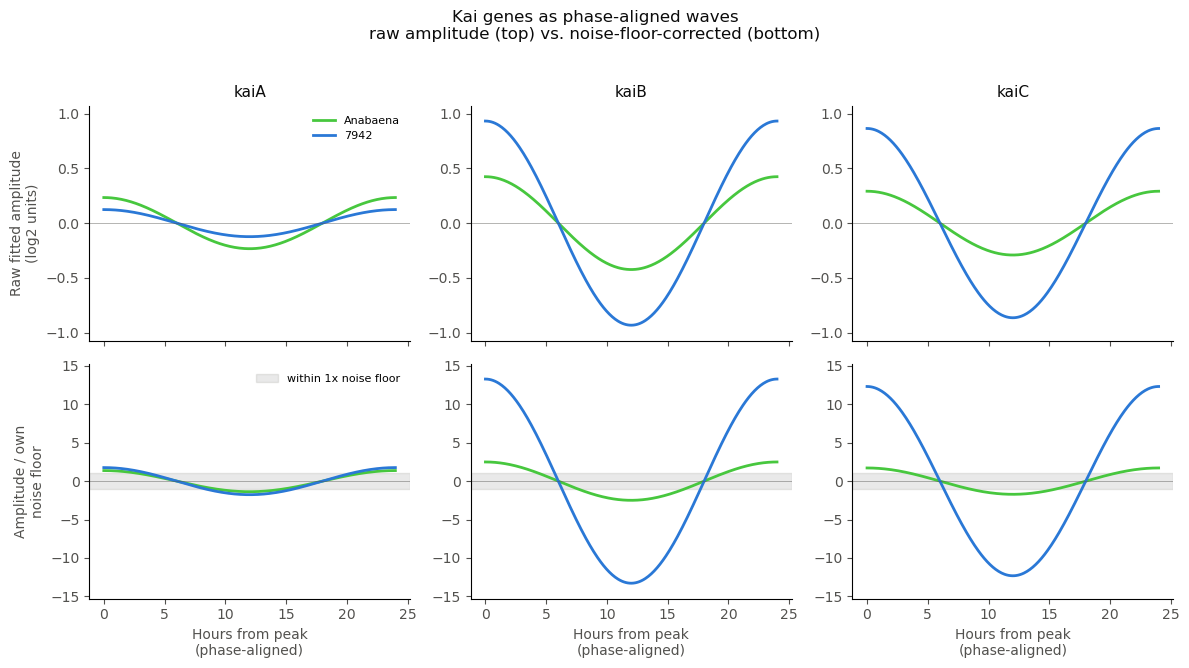

saved /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/figures/16_kai_phase_aligned_waves.png


In [11]:
wave_genes = kai_df[kai_df["gene"].isin(["kaiA", "kaiB", "kaiC"])].sort_values("gene").reset_index(drop=True)
t = np.linspace(0, 24, 300)
wave = np.cos(2 * np.pi * t / 24)  # peak forced to t=0 -- the phase-alignment itself

fig, axes = plt.subplots(2, len(wave_genes), figsize=(4 * len(wave_genes), 6.5), sharex=True)

raw_max = wave_genes[["amplitude_anabaena", "amplitude_vijayan"]].to_numpy().max()
corr_max = max(wave_genes["ratio_to_anabaena_noise"].max(), wave_genes["ratio_to_7942_noise"].max())

for j, (_, row) in enumerate(wave_genes.iterrows()):
    # --- top row: raw fitted amplitude, shared y-axis ---
    ax = axes[0, j]
    ax.plot(t, row["amplitude_anabaena"] * wave, color="#47C73E", linewidth=2, label="Anabaena")
    ax.plot(t, row["amplitude_vijayan"] * wave, color="#2a78d6", linewidth=2, label="7942")
    ax.axhline(0, color=TEXT_SECONDARY, linewidth=0.6, alpha=0.5)
    ax.set_ylim(-raw_max * 1.15, raw_max * 1.15)
    ax.set_title(row["gene"], color=TEXT_PRIMARY, fontsize=11)
    ax.tick_params(colors=TEXT_SECONDARY)
    sns.despine(ax=ax)
    if j == 0:
        ax.set_ylabel("Raw fitted amplitude\n(log2 units)", color=TEXT_SECONDARY)
        ax.legend(frameon=False, fontsize=8, loc="upper right")

    # --- bottom row: noise-floor-corrected, shared y-axis, +/-1 = noise floor ---
    ax = axes[1, j]
    ax.axhspan(-1, 1, color=TEXT_SECONDARY, alpha=0.12, label="within 1x noise floor" if j == 0 else None)
    ax.plot(t, row["ratio_to_anabaena_noise"] * wave, color="#47C73E", linewidth=2)
    ax.plot(t, row["ratio_to_7942_noise"] * wave, color="#2a78d6", linewidth=2)
    ax.axhline(0, color=TEXT_SECONDARY, linewidth=0.6, alpha=0.5)
    ax.set_ylim(-corr_max * 1.15, corr_max * 1.15)
    ax.set_xlabel("Hours from peak\n(phase-aligned)", color=TEXT_SECONDARY)
    ax.tick_params(colors=TEXT_SECONDARY)
    sns.despine(ax=ax)
    if j == 0:
        ax.set_ylabel("Amplitude / own\nnoise floor", color=TEXT_SECONDARY)
        ax.legend(frameon=False, fontsize=8, loc="upper right")

fig.suptitle("Kai genes as phase-aligned waves\n"
             "raw amplitude (top) vs. noise-floor-corrected (bottom)",
             color=TEXT_PRIMARY, fontsize=12, y=1.02)
plt.tight_layout()
fig16 = FIGURES / "16_kai_phase_aligned_waves.png"
plt.savefig(fig16, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fig16}")

## F6 — the decision, stated plainly

Three possible outcomes were named in advance:

- (a) Anabaena globally lower once corrected, and *kaiB* unremarkable in absolute terms
  -> Kushige's headline stands, the 90th-percentile result is only about rank within a
  quiet(er-relative-to-noise) genome.
- (b) distributions comparable and *kaiB* holds up absolutely -> the headline is at
  least partly a CV artifact.
- (c) the noise floors differ enough to swamp the comparison -> neither conclusion is
  available from these two datasets.

**This lands on (a).** Once each organism's amplitude is judged against its own noise
floor rather than compared raw, 7942 oscillates substantially more strongly than
Anabaena (paired, noise-corrected Wilcoxon p=8.7e-119 in the direction opposite the raw
comparison). *kaiB* specifically: 90th percentile within Anabaena but only ~2.5x
Anabaena's own noise floor, against its 7942 ortholog at the 99th percentile and ~13x
7942's noise floor -- roughly a 5x gap in noise-relative terms. Long-form *kaiB*
(all3328, no 7942 ortholog) sits at 0.78x Anabaena's noise floor, i.e. indistinguishable
from noise, consistent with its arrhythmic call.

This is (c)'s scenario ruled OUT, not landed on, specifically because the raw and
corrected comparisons point in opposite, statistically overwhelming directions rather
than both being ambiguous -- if the noise floors were merely "different enough to
confound," the corrected comparison would be muddy, not a clean, larger-magnitude
reversal of the raw one. And per F4, the one identified confound that could have
produced this result artificially (ratio-array compression) points the WRONG way to
explain it -- it would understate 7942's amplitude, not inflate it -- which is exactly
why a confound that could rescue the alternative reading has to be reported even when
it fails to rescue it.

**Kushige's "kai genes barely cycle in Anabaena" headline stands.** The Part B finding
that *kaiB* jumps from the 27th to the 90th amplitude percentile when CV is replaced by
a proper cosinor fit is real (H3 was a genuine problem) -- but that rank shift happened
within a distribution that is itself running much closer to its own noise floor than
7942's. "High-ranking" and "quiet, on an absolute noise-relative basis" are both true at
once, and this is the analysis that finally distinguishes them.